**IMPORTANT**
This is dummy data! model works


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt


from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import GenericStocks, MaterialIntensities

from imagematerials.preprocessing import get_preprocessing_data
from imagematerials.appliances.preprocessing.main import appliances_preprocessing

import prism

from pathlib import Path
from importlib.resources import files

prism.unit_registry.load_definitions(files("imagematerials") / "units.txt")
ureg = prism.unit_registry


In [ ]:
scenario_list = {"SSP2_baseline":("SSP2_baseline", None)}

In [ ]:
climate_scen = "SSP2_baseline"
image_data = Path("..", "data", "raw", "image", climate_scen)

In [ ]:
time_start = 1971
complete_timeline = prism.Timeline(1971, 2100, 1)
simulation_timeline = prism.Timeline(1971, 2100, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path("..", "data", "raw", "image", climate_scen)
    circular_economy_scenario_dirs = None

    appliances_sector = get_preprocessing_data("appliances", 
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dirs) 

    factory = ModelFactory(
    [appliances_sector], complete_timeline
    ).add(GenericStocks, ["appliances"]
    ).add(MaterialIntensities, "appliances",
)
    model = factory.finish()

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

    print(f"Finished {scen_id}")

In [ ]:
inflow_materials = model.appliances.get("inflow_materials").to_array().sum(["Region"]).pint.to("Mt")
stocks_materials = model.appliances.get("stock_by_cohort_materials").sum(["Region"]).pint.to("Mt")
outflow_materials = model.appliances.get("outflow_by_cohort_materials").to_array().sum(["Region"]).pint.to("Mt")

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\varia

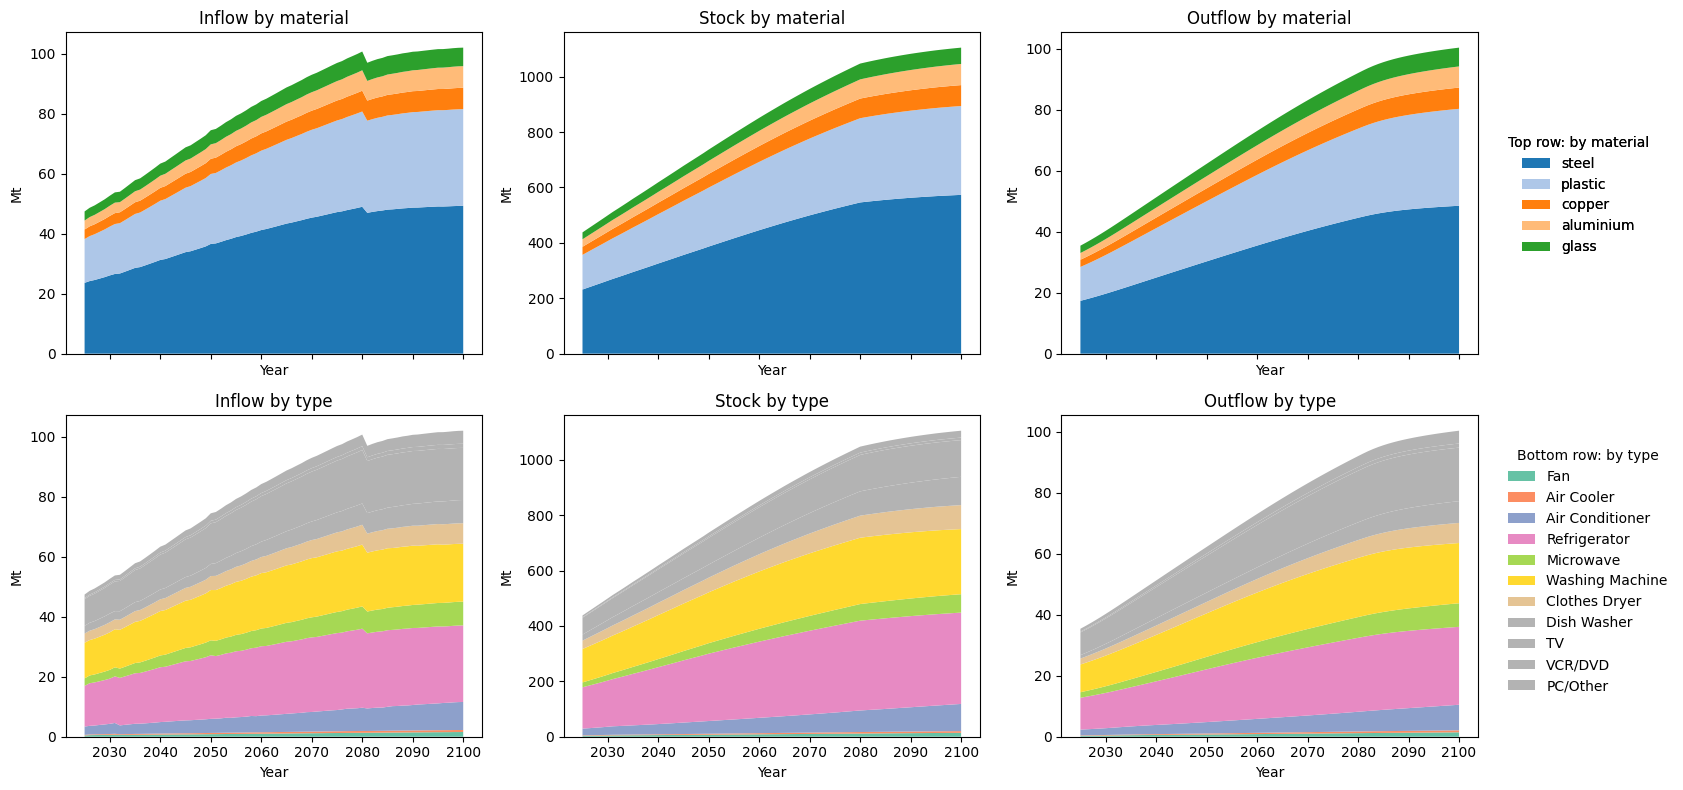

In [10]:
# Inflow, stock and outflow of materials for appliances, stacked by material (top row) and by type (bottom row)

start_year = 2025


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

# Distinct color sets so the "by material" row and the "by type" row never share a color
material_names = inflow_materials.material.values
type_names = inflow_materials.Type.values
material_colors = plt.cm.tab20(range(len(material_names)))
type_colors = plt.cm.Set2(range(len(type_names)))

ax1.stackplot(
    inflow_materials.time.loc[start_year:],
    [inflow_materials.sum("Type").sel(material=m).loc[start_year:] for m in material_names],
    labels=material_names, colors=material_colors,
)

ax2.stackplot(
    stocks_materials.time.loc[start_year:],
    [stocks_materials.sum("Type").sel(material=m).loc[start_year:] for m in material_names],
    labels=material_names, colors=material_colors,
)

ax3.stackplot(
    outflow_materials.time.loc[start_year:],
    [outflow_materials.sum("Type").sel(material=m).loc[start_year:] for m in material_names],
    labels=material_names, colors=material_colors,
)

ax4.stackplot(
    inflow_materials.time.loc[start_year:],
    [inflow_materials.sum("material").sel(Type=t).loc[start_year:] for t in type_names],
    labels=type_names, colors=type_colors,
)

ax5.stackplot(
    stocks_materials.time.loc[start_year:],
    [stocks_materials.sum("material").sel(Type=t).loc[start_year:] for t in type_names],
    labels=type_names, colors=type_colors,
)

ax6.stackplot(
    outflow_materials.time.loc[start_year:],
    [outflow_materials.sum("material").sel(Type=t).loc[start_year:] for t in type_names],
    labels=type_names, colors=type_colors,
)

# Titles: columns are inflow / stock / outflow, rows are "by material" / "by type"
ax1.set_title("Inflow by material")
ax2.set_title("Stock by material")
ax3.set_title("Outflow by material")
ax4.set_title("Inflow by type")
ax5.set_title("Stock by type")
ax6.set_title("Outflow by type")

for ax in axes.flatten():
    ax.set_xlabel('Year')
    ax.set_ylabel('Mt')

# Separate legend per row: top row is split by material, bottom row by appliance type
handles_materials, labels_materials = ax1.get_legend_handles_labels()
handles_types, labels_types = ax4.get_legend_handles_labels()

legend_materials = fig.legend(
    handles_materials, labels_materials,
    loc="center left", bbox_to_anchor=(1.0, 0.75), frameon=False,
    title="Top row: by material",
)
fig.add_artist(legend_materials)

fig.legend(
    handles_types, labels_types,
    loc="center left", bbox_to_anchor=(1.0, 0.28), frameon=False,
    title="Bottom row: by type",
)

fig.tight_layout()
plt.show()